# TSI vs SW Cloud Flag at Gothic

This notebook compares **TSI cloud fraction** to a **shortwave cloud flag** built from
observed incoming shortwave divided by a **clear-sky reference** at Gothic.

Rules used here:

- `SWobs / SWclr < 0.50` -> `cloudy`
- `SWobs / SWclr > 0.85` -> `clear`
- otherwise -> `ambiguous`
- evaluate only **9:00 AM to 2:00 PM local time** at Gothic, before the sun goes behind the mountain

Notes:

- TSI timestamps are treated as **UTC** and converted to `America/Denver`.
- The ARM Gothic SW daily-file timestamps are built from the filename date as **UTC** and converted to `America/Denver`.
- Clear-sky SW is computed from solar geometry using `pysolar` and adjusted with
  site meteorology (air temperature, relative humidity, and pressure when available) from
  `/glade/u/home/cdalden/scratch/surface_obs/colorado/sos_full_dataset_30min.nc`.
- The clear-sky estimate explicitly uses the configured site elevation to pressure-correct
  optical air mass for the reduced atmospheric path length at high elevation.
- `pysolar` is required because the met-adjusted clear-sky calculation needs direct
  control of the pressure-corrected optical air mass.
- The modeled clear-sky SW is scaled using the known-clear window April 29, 2023,
  15:00-20:00 UTC.


In [1]:
from pathlib import Path
from importlib import import_module
from importlib.util import find_spec
import os
import re

import numpy as np
import pandas as pd
import xarray as xr
os.environ.setdefault("MPLCONFIGDIR", "/glade/derecho/scratch/cdalden/tmp/matplotlib")
import matplotlib.pyplot as plt

_PYSOLAR_AVAILABLE = find_spec("pysolar") is not None
if _PYSOLAR_AVAILABLE:
    _pysolar_solar = import_module("pysolar.solar")
    _pysolar_radiation = import_module("pysolar.radiation")
    pysolar_get_altitude = _pysolar_solar.get_altitude
    pysolar_get_radiation_direct = _pysolar_radiation.get_radiation_direct
    pysolar_get_apparent_extraterrestrial_flux = _pysolar_radiation.get_apparent_extraterrestrial_flux
    pysolar_get_optical_depth = _pysolar_radiation.get_optical_depth
else:
    pysolar_get_altitude = None
    pysolar_get_radiation_direct = None
    pysolar_get_apparent_extraterrestrial_flux = None
    pysolar_get_optical_depth = None
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 16
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

TSI_CSV = Path("/glade/u/home/cdalden/scratch/surface_obs/colorado/sail_tsi_cloud_frac.csv")
SW_DAILY_DIR = Path("/glade/u/home/cdalden/scratch/surface_obs/colorado/gucsebsM1.b1")
SW_DAILY_VAR = "down_short_hemisp"
SOS_MET_NC = Path("/glade/u/home/cdalden/scratch/surface_obs/colorado/sos_full_dataset_30min.nc")

LOCAL_TZ = "America/Denver"
LOCAL_START = "09:00"
LOCAL_END = "16:00"
TIME_STEP_MIN = 30

GOTHIC_LAT = 38.96
GOTHIC_LON = -106.99
GOTHIC_ELEV_M = 2880

CLOUDY_RATIO = 0.50
CLEAR_RATIO = 0.85

CLEAR_SKY_CALIBRATION_START_UTC = pd.Timestamp("2023-04-29 15:00:00")
CLEAR_SKY_CALIBRATION_END_UTC = pd.Timestamp("2023-04-29 20:00:00")
CLEAR_SKY_CALIBRATION_QUANTILE = 0.95

if _PYSOLAR_AVAILABLE:
    CLEAR_SKY_METHOD = "pysolar_pressure_water_vapor_adjusted"
else:
    CLEAR_SKY_METHOD = "unavailable_pysolar_required"

TEMP_VAR_CANDIDATES = [
    "T_2m_c",
    "T_3m_c",
    "T_1m_c",
    "air_temp",
    "air_temperature",
    "temperature",
    "temp",
    "ta",
]
RH_VAR_CANDIDATES = [
    "RH_2m_c",
    "RH_3m_c",
    "RH_1m_c",
    "relative_humidity",
    "rh",
    "rh_mean",
    "relhum",
]
PRESSURE_VAR_CANDIDATES = [
    "P_10m_c",
    "P_20m_c",
    "pressure",
    "air_pressure",
    "station_pressure",
]

In [2]:
def _pick_var_name(ds, candidates, label):
    """Find a variable name in ds using candidate names (case-insensitive)."""
    lower_lookup = {name.lower(): name for name in ds.data_vars}
    for candidate in candidates:
        if candidate.lower() in lower_lookup:
            return lower_lookup[candidate.lower()]
    raise KeyError(f"Could not find {label} variable in {list(ds.data_vars)}")


def _pick_optional_var_name(ds, candidates):
    """Find an optional variable name in ds using candidate names (case-insensitive)."""
    lower_lookup = {name.lower(): name for name in ds.data_vars}
    for candidate in candidates:
        if candidate.lower() in lower_lookup:
            return lower_lookup[candidate.lower()]
    return None


def _datetime64ns(values):
    """Normalize datetimes to pandas-compatible nanosecond precision for merges."""
    return np.asarray(pd.to_datetime(values), dtype="datetime64[ns]")


def read_sos_met_30min(
    sos_nc_path=SOS_MET_NC,
    local_tz=LOCAL_TZ,
    temp_candidates=TEMP_VAR_CANDIDATES,
    rh_candidates=RH_VAR_CANDIDATES,
    pressure_candidates=PRESSURE_VAR_CANDIDATES,
):
    """Load 30-min temperature and relative humidity from SOS and convert to local time."""
    if not Path(sos_nc_path).exists():
        raise FileNotFoundError(f"SOS meteorology file not found: {sos_nc_path}")

    with xr.open_dataset(sos_nc_path, decode_times=True) as ds:
        time_name = None
        for name in ds.coords:
            if np.issubdtype(ds[name].dtype, np.datetime64):
                time_name = name
                break
        if time_name is None:
            for name in ds.variables:
                if np.issubdtype(ds[name].dtype, np.datetime64):
                    time_name = name
                    break
        if time_name is None:
            raise KeyError("No datetime coordinate found in SOS dataset")

        temp_var = _pick_var_name(ds, temp_candidates, "temperature")
        rh_var = _pick_var_name(ds, rh_candidates, "relative humidity")
        pressure_var = _pick_optional_var_name(ds, pressure_candidates)

        met_data = {
            "time": pd.to_datetime(ds[time_name].to_numpy()),
            "temp_c": np.asarray(ds[temp_var].to_numpy(), dtype=float),
            "rh_pct": np.asarray(ds[rh_var].to_numpy(), dtype=float),
        }
        if pressure_var is not None:
            met_data["pressure_hpa"] = np.asarray(ds[pressure_var].to_numpy(), dtype=float)
        met_df = pd.DataFrame(met_data)

    met_df = met_df.dropna(subset=["time"]).copy()
    met_df["time_local"] = (
        pd.DatetimeIndex(met_df["time"])
        .tz_localize("UTC")
        .tz_convert(local_tz)
        .tz_localize(None)
)
    met_df["time_local"] = _datetime64ns(met_df["time_local"])
    keep_cols = ["time_local", "temp_c", "rh_pct"]
    if "pressure_hpa" in met_df:
        keep_cols.append("pressure_hpa")
    met_df = met_df[keep_cols].copy()
    met_df["rh_pct"] = met_df["rh_pct"].clip(0, 100)
    met_df = met_df.sort_values("time_local").drop_duplicates("time_local", keep="last").reset_index(drop=True)

    print(
        f"Loaded SOS met from {sos_nc_path}: {len(met_df)} rows "
        f"from {met_df['time_local'].min()} to {met_df['time_local'].max()} "
        f"using temp={temp_var}, rh={rh_var}, pressure={pressure_var or 'elevation_fallback'}"
)
    return met_df


def build_clear_sky_with_met_inputs(times_local, met_df, lat, lon, elev_m, local_tz):
    """Build clear-sky SW using pysolar, elevation, humidity, and air temperature."""
    if not _PYSOLAR_AVAILABLE:
        raise ModuleNotFoundError(
            "pysolar is required for this notebook. Install it with: pip install pysolar"
        )
    if (
        pysolar_get_altitude is None
        or pysolar_get_apparent_extraterrestrial_flux is None
        or pysolar_get_optical_depth is None
    ):
        raise RuntimeError("pysolar import hooks are unavailable")

    get_altitude = pysolar_get_altitude
    get_apparent_extraterrestrial_flux = pysolar_get_apparent_extraterrestrial_flux
    get_optical_depth = pysolar_get_optical_depth

    base = pd.DataFrame({"time_local": _datetime64ns(times_local)}).dropna()
    base = base.sort_values("time_local").drop_duplicates("time_local", keep="last").reset_index(drop=True)

    met_sorted = met_df.sort_values("time_local").reset_index(drop=True).copy()
    met_sorted["time_local"] = _datetime64ns(met_sorted["time_local"])
    merged = pd.merge_asof(
        base,
        met_sorted,
        on="time_local",
        direction="nearest",
        tolerance=pd.Timedelta(minutes=TIME_STEP_MIN // 2 + 1),
    )

    merged["temp_c"] = merged["temp_c"].interpolate(limit_direction="both")
    merged["rh_pct"] = merged["rh_pct"].interpolate(limit_direction="both").clip(0, 100)

    pressure_from_elev_hpa = 1013.25 * (1.0 - 2.25577e-5 * elev_m) ** 5.25588
    if "pressure_hpa" in merged:
        merged["pressure_hpa"] = merged["pressure_hpa"].interpolate(limit_direction="both")
        merged["pressure_hpa"] = merged["pressure_hpa"].fillna(pressure_from_elev_hpa)
    else:
        merged["pressure_hpa"] = pressure_from_elev_hpa

    time_utc = pd.DatetimeIndex(merged["time_local"]).tz_localize(local_tz).tz_convert("UTC")
    time_py = time_utc.to_pydatetime()

    solar_altitude_deg = np.array([get_altitude(lat, lon, t) for t in time_py], dtype=float)
    positive_alt = np.clip(solar_altitude_deg, 0.0, None)
    solar_alt_rad = np.deg2rad(positive_alt)

    pressure_hpa = merged["pressure_hpa"].to_numpy(dtype=float)
    pressure_ratio = np.clip(pressure_hpa / 1013.25, 0.45, 1.05)
    sin_alt_safe = np.clip(np.sin(solar_alt_rad), 0.05, None)
    standard_airmass = 1.0 / sin_alt_safe
    pressure_corrected_airmass = standard_airmass * pressure_ratio

    day_of_year = np.array([t.timetuple().tm_yday for t in time_py], dtype=int)
    extraterrestrial_flux = np.array(
        [get_apparent_extraterrestrial_flux(day) for day in day_of_year],
        dtype=float,
    )
    optical_depth = np.array([get_optical_depth(day) for day in day_of_year], dtype=float)
    dni_standard = extraterrestrial_flux * np.exp(-optical_depth * standard_airmass)
    dni_clear = extraterrestrial_flux * np.exp(-optical_depth * pressure_corrected_airmass)
    dni_standard[positive_alt <= 0] = 0.0
    dni_clear[positive_alt <= 0] = 0.0
    elevation_scale = np.divide(
        dni_clear,
        dni_standard,
        out=np.ones_like(dni_clear),
        where=dni_standard > 0,
    )
    elevation_scale = np.clip(elevation_scale, 1.0, 1.25)
    dni_clear = dni_standard * elevation_scale
    ghi_clear = dni_clear * np.sin(solar_alt_rad)

    # Estimate water-vapor attenuation from SOS temperature and RH.
    temp_c = merged["temp_c"].to_numpy(dtype=float)
    rh_frac = (merged["rh_pct"].to_numpy(dtype=float) / 100.0).clip(0.0, 1.0)
    saturation_vapor_pressure_hpa = 6.112 * np.exp((17.67 * temp_c) / (temp_c + 243.5))
    vapor_pressure_hpa = rh_frac * saturation_vapor_pressure_hpa
    water_vapor_path = np.clip(vapor_pressure_hpa * pressure_corrected_airmass / 10.0, 0.0, 8.0)
    water_vapor_scale = np.clip(np.exp(-0.035 * water_vapor_path), 0.72, 1.0)

    sw_clear = ghi_clear * water_vapor_scale
    sw_clear[positive_alt <= 0] = 0.0

    out = merged.copy()
    out["solar_altitude_deg"] = solar_altitude_deg
    out["site_elev_m"] = float(elev_m)
    out["pressure_from_elev_hpa"] = pressure_from_elev_hpa
    out["vapor_pressure_hpa"] = vapor_pressure_hpa
    out["elevation_scale"] = elevation_scale
    out["water_vapor_scale"] = water_vapor_scale
    out["pressure_corrected_airmass"] = pressure_corrected_airmass
    out["sw_clear"] = sw_clear
    return out[
        [
            "time_local",
            "sw_clear",
            "temp_c",
            "rh_pct",
            "pressure_hpa",
            "site_elev_m",
            "pressure_from_elev_hpa",
            "vapor_pressure_hpa",
            "elevation_scale",
            "water_vapor_scale",
            "pressure_corrected_airmass",
            "solar_altitude_deg",
        ]
    ]


def pick_example_day(df):
    day_scores = (
        df.assign(date=df["time_local"].dt.normalize())
        .groupby("date")
        .agg(
            n=("time_local", "size"),
            n_clear=("sw_flag", lambda s: (s == "clear").sum()),
            n_cloudy=("sw_flag", lambda s: (s == "cloudy").sum()),
        )
    )
    day_scores["score"] = day_scores["n_clear"] * day_scores["n_cloudy"]
    return day_scores.sort_values(["score", "n"], ascending=False).index[0]


def frac_by_flag(series, label):
    return (series == label).mean()


def apply_known_clear_sky_calibration(
    sw_df,
    clear_df,
    start_utc=CLEAR_SKY_CALIBRATION_START_UTC,
    end_utc=CLEAR_SKY_CALIBRATION_END_UTC,
    quantile=CLEAR_SKY_CALIBRATION_QUANTILE,
    local_tz=LOCAL_TZ,
):
    """Scale modeled clear sky using a known-clear UTC window."""
    calibration_df = (
        sw_df[["time_local", "sw_obs"]]
        .merge(clear_df, on="time_local", how="inner")
        .sort_values("time_local")
        .reset_index(drop=True)
    )
    calibration_utc = (
        pd.DatetimeIndex(calibration_df["time_local"])
        .tz_localize(local_tz)
        .tz_convert("UTC")
        .tz_localize(None)
    )
    window = (
        (calibration_utc >= pd.Timestamp(start_utc))
        & (calibration_utc <= pd.Timestamp(end_utc))
        & calibration_df["sw_obs"].notna()
        & calibration_df["sw_clear"].notna()
        & (calibration_df["sw_clear"] > 0)
    )
    known_clear = calibration_df.loc[window].copy()
    if known_clear.empty:
        raise ValueError(
            f"No SW/clear-sky samples found for known-clear calibration window {start_utc} to {end_utc} UTC"
        )
    known_clear["sw_ratio_raw"] = known_clear["sw_obs"] / known_clear["sw_clear"]
    clear_sky_scale = float(known_clear["sw_ratio_raw"].quantile(quantile))
    if not np.isfinite(clear_sky_scale) or clear_sky_scale <= 0:
        raise ValueError(f"Invalid clear-sky calibration scale: {clear_sky_scale}")

    calibrated = clear_df.copy()
    calibrated["sw_clear_raw"] = calibrated["sw_clear"]
    calibrated["sw_clear_calibration_scale"] = clear_sky_scale
    calibrated["sw_clear_calibration_window_utc"] = f"{start_utc} to {end_utc}"
    calibrated["sw_clear"] = calibrated["sw_clear_raw"] * clear_sky_scale
    return calibrated, known_clear, clear_sky_scale


def read_gothic_sw_daily_files(sw_daily_dir=SW_DAILY_DIR, sw_daily_var=SW_DAILY_VAR, local_tz=LOCAL_TZ):
    files = sorted(Path(sw_daily_dir).glob("gucsebsM1.b1.*.custom.cdf"))
    rows = []

    for path in files:
        match = re.search(r"\.(\d{8})\.", path.name)
        if not match:
            continue
        file_day_utc = pd.Timestamp(match.group(1))

        with xr.open_dataset(path, decode_times=True) as ds:
            if sw_daily_var not in ds:
                raise KeyError(f"Expected {sw_daily_var} in {path}")
            values = np.asarray(ds[sw_daily_var].to_numpy(), dtype=float)

        time_utc = pd.date_range(file_day_utc, periods=len(values), freq="30min")
        time_local = time_utc.tz_localize("UTC").tz_convert(local_tz).tz_localize(None)
        time_local = _datetime64ns(time_local)
        rows.append(
            pd.DataFrame(
                {
                    "time_local": time_local,
                    "sw_obs": values,
                    "sw_obs_var": sw_daily_var,
                    "sw_obs_source": str(path),
                }
            )
        )

    if not rows:
        raise FileNotFoundError(f"No {sw_daily_var} daily files found in {sw_daily_dir}")

    sw = pd.concat(rows, ignore_index=True)
    sw = sw.dropna(subset=["time_local", "sw_obs"]).sort_values("time_local")
    sw = sw.drop_duplicates("time_local", keep="last").reset_index(drop=True)
    print(
        f"Loaded SW daily files from {sw_daily_dir}: "
        f"{len(sw)} valid {sw_daily_var} rows from "
        f"{sw['time_local'].min()} to {sw['time_local'].max()}"
    )
    return sw



In [3]:
sw_df = read_gothic_sw_daily_files()
sos_met_df = read_sos_met_30min()


tsi_df = pd.read_csv(TSI_CSV, parse_dates=["t"])
tsi_df["time_local"] = (
    tsi_df["t"]
    .dt.tz_localize("UTC")
    .dt.tz_convert(LOCAL_TZ)
    .dt.tz_localize(None)
)
tsi_df["time_local"] = _datetime64ns(tsi_df["time_local"])
tsi_df = tsi_df[["time_local", "tsi_frac"]].dropna(subset=["time_local"])
tsi_order = np.argsort(tsi_df["time_local"].to_numpy(dtype="datetime64[ns]"))
tsi_df = tsi_df.iloc[tsi_order].reset_index(drop=True)

tsi_30 = (
    tsi_df.set_index("time_local")
    .resample(f"{TIME_STEP_MIN}min")
    .mean()
    .reset_index()
)
tsi_30["time_local"] = _datetime64ns(tsi_30["time_local"])

overlap_start = max(
    sw_df["time_local"].min(),
    tsi_30["time_local"].min(),
    sos_met_df["time_local"].min(),
)
overlap_end = min(
    sw_df["time_local"].max(),
    tsi_30["time_local"].max(),
    sos_met_df["time_local"].max(),
)

sw_df = sw_df[(sw_df["time_local"] >= overlap_start) & (sw_df["time_local"] <= overlap_end)].copy()
tsi_30 = tsi_30[(tsi_30["time_local"] >= overlap_start) & (tsi_30["time_local"] <= overlap_end)].copy()
sos_met_df = sos_met_df[(sos_met_df["time_local"] >= overlap_start) & (sos_met_df["time_local"] <= overlap_end)].copy()
sw_df["time_local"] = _datetime64ns(sw_df["time_local"])
tsi_30["time_local"] = _datetime64ns(tsi_30["time_local"])
sos_met_df["time_local"] = _datetime64ns(sos_met_df["time_local"])

clear_df = build_clear_sky_with_met_inputs(
    times_local=sw_df["time_local"],
    met_df=sos_met_df,
    lat=GOTHIC_LAT,
    lon=GOTHIC_LON,
    elev_m=GOTHIC_ELEV_M,
    local_tz=LOCAL_TZ,
)
clear_df, clear_sky_calibration_df, clear_sky_calibration_scale = apply_known_clear_sky_calibration(
    sw_df=sw_df,
    clear_df=clear_df,
)

compare_all_df = (
    sw_df.merge(clear_df, on="time_local", how="inner")
    .merge(tsi_30, on="time_local", how="inner")
    .sort_values("time_local")
    .reset_index(drop=True)
)

compare_all_df.loc[compare_all_df["sw_clear"] <= 0, "sw_clear"] = np.nan
compare_all_df["sw_ratio"] = compare_all_df["sw_obs"] / compare_all_df["sw_clear"]

compare_all_df["sw_flag"] = np.select(
    [
        compare_all_df["sw_ratio"] < CLOUDY_RATIO,
        compare_all_df["sw_ratio"] > CLEAR_RATIO,
    ],
    [
        "cloudy",
        "clear",
    ],
    default="ambiguous",
)
compare_all_df["date"] = compare_all_df["time_local"].dt.normalize()

compare_df = compare_all_df.set_index("time_local").between_time(
    LOCAL_START,
    LOCAL_END,
    inclusive="both",
).reset_index()
compare_df


Loaded SW daily files from /glade/u/home/cdalden/scratch/surface_obs/colorado/gucsebsM1.b1: 15644 valid down_short_hemisp rows from 2021-08-31 18:00:00 to 2023-06-16 09:30:00
Loaded SOS met from /glade/u/home/cdalden/scratch/surface_obs/colorado/sos_full_dataset_30min.nc: 11072 rows from 2022-10-31 18:00:00 to 2023-06-19 11:30:00 using temp=T_2m_c, rh=RH_2m_c, pressure=P_10m_c


,time_local,sw_obs,sw_obs_var,sw_obs_source,sw_clear,temp_c,rh_pct,pressure_hpa,site_elev_m,pressure_from_elev_hpa,...,water_vapor_scale,pressure_corrected_airmass,solar_altitude_deg,sw_clear_raw,sw_clear_calibration_scale,sw_clear_calibration_window_utc,tsi_frac,sw_ratio,sw_flag,date
0,2022-11-01 09:00:00,178.226196,down_short_hemisp,/glade/u/home/cdalden/scratch/surface_obs/colo...,190.889065,7.185330,26.430786,719.149963,2880.0,711.850041,...,0.973005,2.916750,14.083427,177.320852,1.076518,2023-04-29 15:00:00 to 2023-04-29 20:00:00,0.006840,0.933664,clear,2022-11-01
1,2022-11-01 09:30:00,265.102509,down_short_hemisp,/glade/u/home/cdalden/scratch/surface_obs/colo...,286.185988,7.049714,26.129553,719.051453,2880.0,711.850041,...,0.979995,2.198902,18.828018,265.844162,1.076518,2023-04-29 15:00:00 to 2023-04-29 20:00:00,0.014510,0.926329,clear,2022-11-01
2,2022-11-01 10:00:00,348.426086,down_short_hemisp,/glade/u/home/cdalden/scratch/surface_obs/colo...,373.828073,6.647303,26.943506,719.118225,2880.0,711.850041,...,0.983534,1.801187,23.205236,347.256731,1.076518,2023-04-29 15:00:00 to 2023-04-29 20:00:00,0.041860,0.932049,clear,2022-11-01
3,2022-11-01 10:30:00,396.683594,down_short_hemisp,/glade/u/home/cdalden/scratch/surface_obs/colo...,450.881219,6.448332,27.562576,719.108337,2880.0,711.850041,...,0.985626,1.556563,27.125659,418.833013,1.076518,2023-04-29 15:00:00 to 2023-04-29 20:00:00,0.032417,0.879796,clear,2022-11-01
4,2022-11-01 11:00:00,493.411713,down_short_hemisp,/glade/u/home/cdalden/scratch/surface_obs/colo...,515.214842,5.575563,30.288132,718.915344,2880.0,711.850041,...,0.986634,1.398348,30.490443,478.593863,1.076518,2023-04-29 15:00:00 to 2023-04-29 20:00:00,0.081875,0.957681,clear,2022-11-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3160,2023-05-31 14:00:00,157.507904,down_short_hemisp,/glade/u/home/cdalden/scratch/surface_obs/colo...,931.212699,4.458038,85.383522,718.805237,2880.0,711.850041,...,0.981163,0.757765,69.419914,865.022990,1.076518,2023-04-29 15:00:00 to 2023-04-29 20:00:00,0.865443,0.169143,cloudy,2023-05-31
3161,2023-05-31 14:30:00,465.476990,down_short_hemisp,/glade/u/home/cdalden/scratch/surface_obs/colo...,898.475949,3.885059,89.152870,718.738037,2880.0,711.850041,...,0.980530,0.781120,65.244763,834.613137,1.076518,2023-04-29 15:00:00 to 2023-04-29 20:00:00,0.927501,0.518074,ambiguous,2023-05-31
3162,2023-05-31 15:00:00,407.407104,down_short_hemisp,/glade/u/home/cdalden/scratch/surface_obs/colo...,852.428542,3.251790,93.219238,718.745911,2880.0,711.850041,...,0.979653,0.816724,60.287916,791.838736,1.076518,2023-04-29 15:00:00 to 2023-04-29 20:00:00,0.852949,0.477937,cloudy,2023-05-31
3163,2023-05-31 15:30:00,632.699829,down_short_hemisp,/glade/u/home/cdalden/scratch/surface_obs/colo...,794.204127,2.991476,93.005463,718.892639,2880.0,711.850041,...,0.978846,0.867214,54.897785,737.752857,1.076518,2023-04-29 15:00:00 to 2023-04-29 20:00:00,0.993851,0.796646,ambiguous,2023-05-31


In [4]:
summary_df = pd.DataFrame(
    {
        "metric": [
            "Overlap start",
            "Overlap end",
            "Rows after local-time filter",
            "Rows with valid TSI",
            "Clear-sky method",
            "Clear-sky elevation (m)",
            "Mean pressure used (hPa)",
            "Pressure from elevation (hPa)",
            "Mean elevation pressure scale",
            "Mean RH used (%)",
            "Mean air temperature used (C)",
            "Mean vapor pressure used (hPa)",
            "Mean water vapor scale",
            "Clear-sky calibration window UTC",
            "Clear-sky calibration quantile",
            "Clear-sky calibration samples",
            "Clear-sky calibration scale",
            "Known-clear raw median SW ratio",
            "Known-clear raw max SW ratio",
            "Rows flagged cloudy",
            "Rows flagged clear",
            "Rows flagged ambiguous",
            "Mean SW ratio",
            "Median SW ratio",
            "Mean TSI fraction",
            "Median TSI fraction",
        ],
        "value": [
            compare_df["time_local"].min(),
            compare_df["time_local"].max(),
            len(compare_df),
            int(compare_df["tsi_frac"].notna().sum()),
            CLEAR_SKY_METHOD,
            GOTHIC_ELEV_M,
            compare_df["pressure_hpa"].mean(),
            compare_df["pressure_from_elev_hpa"].mean(),
            compare_df["elevation_scale"].mean(),
            compare_df["rh_pct"].mean(),
            compare_df["temp_c"].mean(),
            compare_df["vapor_pressure_hpa"].mean(),
            compare_df["water_vapor_scale"].mean(),
            f"{CLEAR_SKY_CALIBRATION_START_UTC} to {CLEAR_SKY_CALIBRATION_END_UTC}",
            CLEAR_SKY_CALIBRATION_QUANTILE,
            len(clear_sky_calibration_df),
            clear_sky_calibration_scale,
            clear_sky_calibration_df["sw_ratio_raw"].median(),
            clear_sky_calibration_df["sw_ratio_raw"].max(),
            int((compare_df["sw_flag"] == "cloudy").sum()),
            int((compare_df["sw_flag"] == "clear").sum()),
            int((compare_df["sw_flag"] == "ambiguous").sum()),
            compare_df["sw_ratio"].mean(),
            compare_df["sw_ratio"].median(),
            compare_df["tsi_frac"].mean(),
            compare_df["tsi_frac"].median(),
        ],
    }
)
summary_df

,metric,value
0,Overlap start,2022-11-01 09:00:00
1,Overlap end,2023-05-31 16:00:00
2,Rows after local-time filter,3165
3,Rows with valid TSI,3106
4,Clear-sky method,pysolar_pressure_water_vapor_adjusted
5,Clear-sky elevation (m),2880
6,Mean pressure used (hPa),716.812924
7,Pressure from elevation (hPa),711.850041
8,Mean elevation pressure scale,1.100438
9,Mean RH used (%),63.750334


In [5]:
tsi_by_flag = (
    compare_df.groupby("sw_flag")
    .agg(
        n=("tsi_frac", "count"),
        tsi_mean=("tsi_frac", "mean"),
        tsi_median=("tsi_frac", "median"),
        tsi_std=("tsi_frac", "std"),
        sw_ratio_mean=("sw_ratio", "mean"),
        sw_ratio_median=("sw_ratio", "median"),
    )
    .sort_index()
    .round(3)
)
tsi_by_flag

,n,tsi_mean,tsi_median,tsi_std,sw_ratio_mean,sw_ratio_median
sw_flag,,,,,,
ambiguous,781,0.657,0.773,0.330,0.675,0.672
clear,1498,0.173,0.034,0.248,1.007,0.988
cloudy,827,0.903,0.986,0.215,0.333,0.344


In [6]:
bin_edges = np.linspace(0, 1, 11)
compare_df["tsi_bin"] = pd.cut(compare_df["tsi_frac"], bin_edges, include_lowest=True)

flag_by_tsi_bin = (
    compare_df.dropna(subset=["tsi_frac"])
    .groupby("tsi_bin", observed=False)["sw_flag"]
    .agg(
        n="size",
        cloudy_fraction=lambda s: frac_by_flag(s, "cloudy"),
        clear_fraction=lambda s: frac_by_flag(s, "clear"),
        ambiguous_fraction=lambda s: frac_by_flag(s, "ambiguous"),
    )
    .round(3)
)
flag_by_tsi_bin

,n,cloudy_fraction,clear_fraction,ambiguous_fraction
tsi_bin,,,,
"(-0.001, 0.1]",971,0.010,0.933,0.057
"(0.1, 0.2]",200,0.055,0.710,0.235
"(0.2, 0.3]",148,0.074,0.682,0.243
"(0.3, 0.4]",144,0.062,0.549,0.389
"(0.4, 0.5]",118,0.085,0.593,0.322
"(0.5, 0.6]",106,0.160,0.415,0.425
"(0.6, 0.7]",108,0.157,0.333,0.509
"(0.7, 0.8]",124,0.161,0.274,0.565
"(0.8, 0.9]",175,0.211,0.240,0.549


/glade/derecho/scratch/cdalden/tmp/ipykernel_41073/1243878725.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(box_data, labels=["clear", "ambiguous", "cloudy"], showfliers=False)


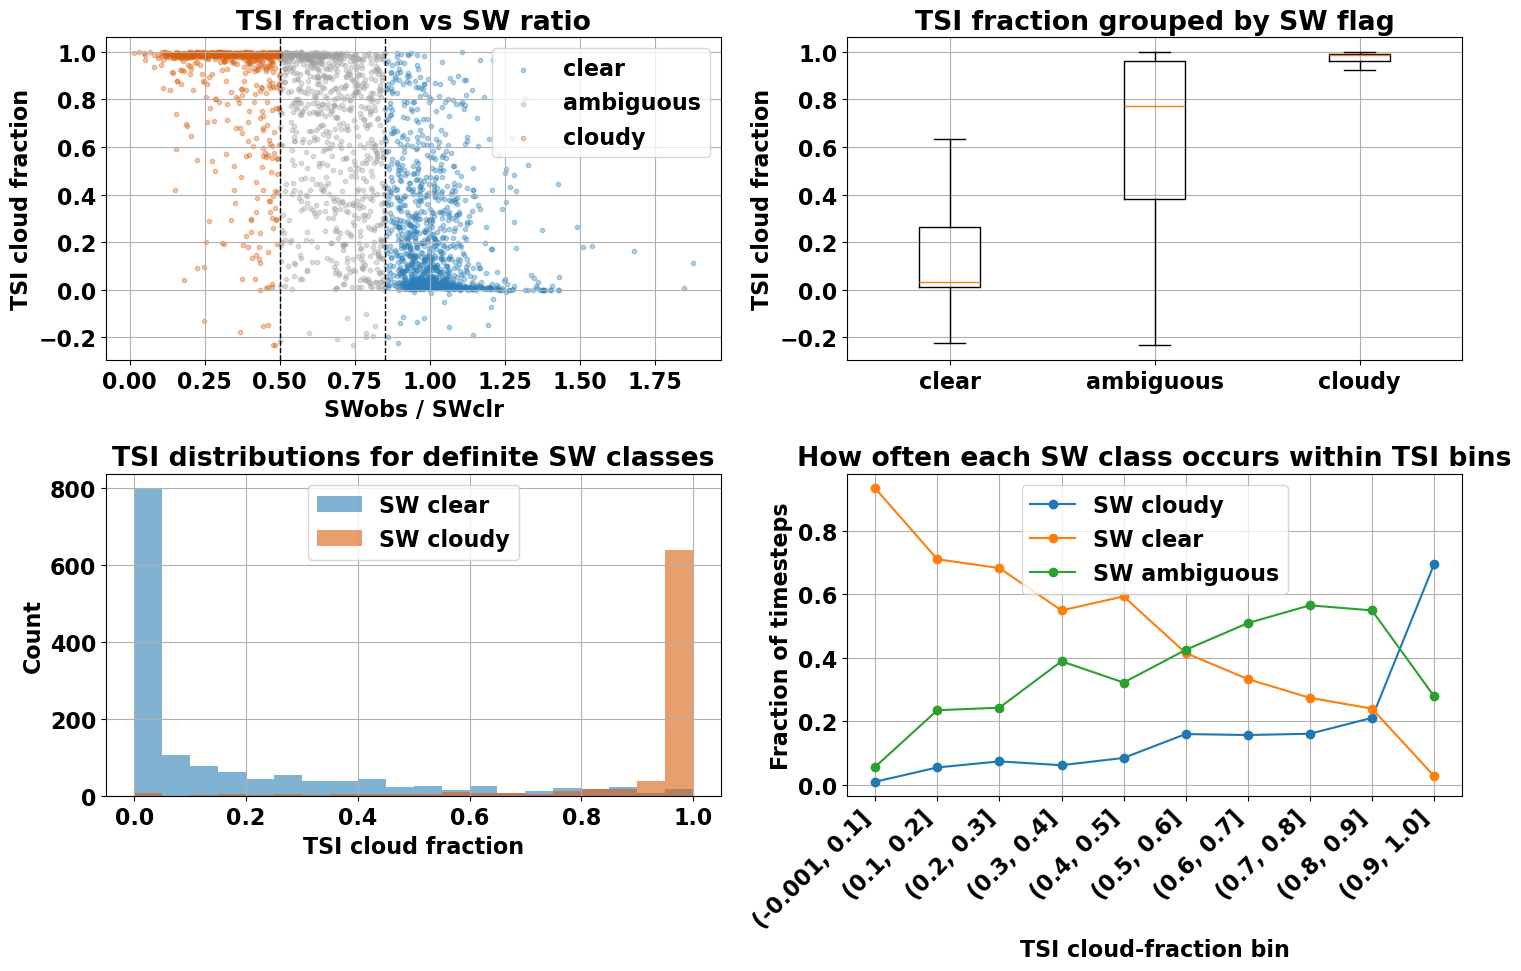

In [7]:
colors = {"clear": "#2c7fb8", "cloudy": "#d95f0e", "ambiguous": "#9e9e9e"}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for flag in ["clear", "ambiguous", "cloudy"]:
    sub = compare_df[compare_df["sw_flag"] == flag]
    axes[0, 0].scatter(
        sub["sw_ratio"],
        sub["tsi_frac"],
        s=10,
        alpha=0.35,
        label=flag,
        color=colors[flag],
    )
axes[0, 0].axvline(CLOUDY_RATIO, color="k", ls="--", lw=1)
axes[0, 0].axvline(CLEAR_RATIO, color="k", ls="--", lw=1)
axes[0, 0].set_xlabel("SWobs / SWclr")
axes[0, 0].set_ylabel("TSI cloud fraction")
axes[0, 0].set_title("TSI fraction vs SW ratio")
axes[0, 0].legend()

box_data = [
    compare_df.loc[compare_df["sw_flag"] == "clear", "tsi_frac"].dropna(),
    compare_df.loc[compare_df["sw_flag"] == "ambiguous", "tsi_frac"].dropna(),
    compare_df.loc[compare_df["sw_flag"] == "cloudy", "tsi_frac"].dropna(),
]
axes[0, 1].boxplot(box_data, labels=["clear", "ambiguous", "cloudy"], showfliers=False)
axes[0, 1].set_ylabel("TSI cloud fraction")
axes[0, 1].set_title("TSI fraction grouped by SW flag")

axes[1, 0].hist(
    compare_df.loc[compare_df["sw_flag"] == "clear", "tsi_frac"].dropna(),
    bins=np.linspace(0, 1, 21),
    alpha=0.6,
    label="SW clear",
    color=colors["clear"],
)
axes[1, 0].hist(
    compare_df.loc[compare_df["sw_flag"] == "cloudy", "tsi_frac"].dropna(),
    bins=np.linspace(0, 1, 21),
    alpha=0.6,
    label="SW cloudy",
    color=colors["cloudy"],
)
axes[1, 0].set_xlabel("TSI cloud fraction")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("TSI distributions for definite SW classes")
axes[1, 0].legend()

bin_centers = np.arange(len(flag_by_tsi_bin))
axes[1, 1].plot(bin_centers, flag_by_tsi_bin["cloudy_fraction"], marker="o", label="SW cloudy")
axes[1, 1].plot(bin_centers, flag_by_tsi_bin["clear_fraction"], marker="o", label="SW clear")
axes[1, 1].plot(bin_centers, flag_by_tsi_bin["ambiguous_fraction"], marker="o", label="SW ambiguous")
axes[1, 1].set_xticks(bin_centers)
axes[1, 1].set_xticklabels([str(x) for x in flag_by_tsi_bin.index], rotation=45, ha="right")
axes[1, 1].set_xlabel("TSI cloud-fraction bin")
axes[1, 1].set_ylabel("Fraction of timesteps")
axes[1, 1].set_title("How often each SW class occurs within TSI bins")
axes[1, 1].legend()

plt.tight_layout()

In [8]:
example_day = pd.Timestamp("2023-05-22")
day_df = compare_df.loc[compare_df["date"].eq(example_day)].copy()

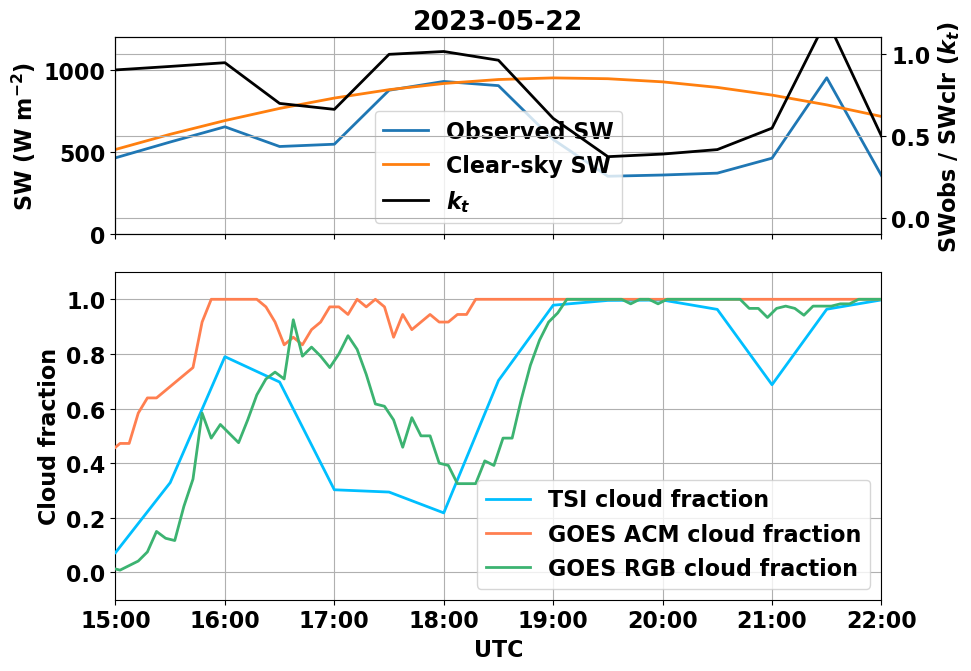

In [9]:
from matplotlib.dates import num2date
from matplotlib.patches import Patch

goes_cf_path = "/glade/u/home/cdalden/goes_work/analysis/output_08c/colorado_domain_cloud_fraction_14z_00z.csv"
goes_cf_df = pd.read_csv(goes_cf_path, parse_dates=["t"])
goes_cf_df["time_local"] = (
    goes_cf_df["t"]
    .dt.tz_localize("UTC")
    .dt.tz_convert(LOCAL_TZ)
    .dt.tz_localize(None)
)
goes_day_df = goes_cf_df.loc[
    goes_cf_df["time_local"].dt.normalize().eq(pd.Timestamp(example_day).normalize())
].copy()

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, height_ratios=[0.6, 1])

axes[0].plot(day_df["time_local"], day_df["sw_obs"], label="Observed SW", lw=2)
# axes[0].plot(day_df["time_local"], day_df["sw_clear_raw"], label="Raw clear-sky SW", lw=1.5, ls="--")
axes[0].plot(day_df["time_local"], day_df["sw_clear"], label="Clear-sky SW", lw=2)
kt_ax = axes[0].twinx()
kt_ax.plot(day_df["time_local"], day_df["sw_ratio"], label="$k_t$", lw=2, color='k', zorder=3)
kt_ax.set_ylabel("SWobs / SWclr ($k_t$)")
kt_ax.set_ylim(-0.1, 1.1)

axes[0].set_ylabel("SW (W m$^{-2}$)")
axes[0].set_title(f"{example_day.date()}")
axes[0].set_ylim(0,1200)
handles, labels = axes[0].get_legend_handles_labels()
kt_handles, kt_labels = kt_ax.get_legend_handles_labels()
axes[0].legend(handles + kt_handles, labels + kt_labels)

shade_half_width = pd.Timedelta(minutes=15)
ratio_clear = day_df["sw_ratio"].gt(CLEAR_RATIO)
ratio_cloudy = day_df["sw_ratio"].lt(CLOUDY_RATIO)
# for mask, color, alpha in [
#     (ratio_clear, "lemonchiffon", 1.0),
#     (ratio_cloudy, "lightblue", 0.5),
# ]:
#     for time in day_df.loc[mask, "time_local"]:
#         axes[1].axvspan(
#             time - shade_half_width,
#             time + shade_half_width,
#             color=color,
#             alpha=alpha,
#             linewidth=0,
#             zorder=0,
#         )

axes[1].plot(day_df["time_local"], day_df["tsi_frac"], label="TSI cloud fraction", lw=2, color='deepskyblue', zorder=4)
axes[1].plot(goes_day_df["time_local"], goes_day_df["acm_cloud_frac"], label="GOES ACM cloud fraction", lw=2, color="coral", zorder=4)
axes[1].plot(goes_day_df["time_local"], goes_day_df["rgb_cloud_frac"], label="GOES RGB cloud fraction", lw=2, color="mediumseagreen", zorder=4)
# axes[1].axhline(CLOUDY_RATIO, color='slategray', ls="--", lw=2, zorder=2)
# axes[1].axhline(CLEAR_RATIO, color='lightslategray', ls="--", lw=2, zorder=2)
axes[1].set_ylabel("Cloud fraction")
axes[1].set_ylim(-0.1, 1.1)
handles, labels = axes[1].get_legend_handles_labels()
# handles.extend([
#     Patch(facecolor="lemonchiffon", edgecolor="none", label="clear timestep ($k_t > 0.85$)"),
#     Patch(facecolor="lightblue", edgecolor="none", alpha=0.5, label=f"cloudy timestep ($k_t < {CLOUDY_RATIO:.2f}$)"),
# ])
axes[1].legend(handles=handles, ncol=1, loc='lower right')

utc_offset = pd.Timestamp(example_day).tz_localize(LOCAL_TZ).utcoffset()
utc_xlim_start = pd.Timestamp(example_day).normalize() + pd.Timedelta(hours=15) + utc_offset
utc_xlim_end = pd.Timestamp(example_day).normalize() + pd.Timedelta(hours=22) + utc_offset
axes[1].set_xlim(utc_xlim_start, utc_xlim_end)
axes[1].xaxis.set_major_formatter(
    lambda x, pos: (pd.Timestamp(num2date(x)).tz_localize(None) - utc_offset).strftime("%H:%M")
)
axes[1].set_xlabel("UTC")

plt.tight_layout()

In [10]:
day_table = day_df[["time_local", "sw_obs", "sw_clear_raw", "sw_clear", "sw_ratio", "tsi_frac", "sw_flag"]].copy()
for col in ["sw_obs", "sw_clear_raw", "sw_clear", "sw_ratio", "tsi_frac"]:
    day_table[col] = day_table[col].round(3)
day_table.head(20)

,time_local,sw_obs,sw_clear_raw,sw_clear,sw_ratio,tsi_frac,sw_flag
3015,2023-05-22 09:00:00,464.664,479.027,515.681,0.901,0.072,clear
3016,2023-05-22 09:30:00,561.199,565.159,608.403,0.922,0.329,clear
3017,2023-05-22 10:00:00,654.082,642.818,692.005,0.945,0.790,clear
3018,2023-05-22 10:30:00,533.806,711.759,766.221,0.697,0.697,ambiguous
3019,2023-05-22 11:00:00,547.748,770.370,829.317,0.660,0.303,ambiguous
3020,2023-05-22 11:30:00,877.186,817.918,880.503,0.996,0.294,clear
3021,2023-05-22 12:00:00,930.804,853.094,918.371,1.014,0.218,clear
3022,2023-05-22 12:30:00,905.155,875.633,942.635,0.960,0.702,clear
3023,2023-05-22 13:00:00,576.646,884.731,952.429,0.605,0.978,ambiguous
3024,2023-05-22 13:30:00,352.198,880.082,947.423,0.372,0.996,cloudy


In [11]:
# Days where calibrated clear-sky SW is still lower than observed SW
RATIO_EXCEEDANCE_THRESHOLD = 1.0
OUT_RATIO_EXCEEDANCE_DATES = "sw_ratio_gt1_candidate_dates.csv"

ratio_exceedance_df = compare_df.loc[
    compare_df["sw_ratio"].gt(RATIO_EXCEEDANCE_THRESHOLD)
].copy()

daily_ratio_exceedance = (
    compare_df.assign(ratio_gt1=compare_df["sw_ratio"].gt(RATIO_EXCEEDANCE_THRESHOLD))
    .groupby("date")
    .agg(
        n_total=("sw_ratio", "size"),
        n_ratio_gt1=("ratio_gt1", "sum"),
        max_ratio=("sw_ratio", "max"),
        mean_ratio=("sw_ratio", "mean"),
        median_ratio=("sw_ratio", "median"),
        max_obs_sw=("sw_obs", "max"),
        max_clear_sw=("sw_clear", "max"),
        mean_tsi_frac=("tsi_frac", "mean"),
        min_tsi_frac=("tsi_frac", "min"),
    )
)
daily_ratio_exceedance["frac_ratio_gt1"] = daily_ratio_exceedance["n_ratio_gt1"] / daily_ratio_exceedance["n_total"]

daily_ratio_exceedance = (
    daily_ratio_exceedance.loc[daily_ratio_exceedance["n_ratio_gt1"] > 0]
    .sort_values(["max_ratio", "frac_ratio_gt1", "n_ratio_gt1"], ascending=False)
    .reset_index()
)
daily_ratio_exceedance["date"] = daily_ratio_exceedance["date"].dt.date
daily_ratio_exceedance.to_csv(OUT_RATIO_EXCEEDANCE_DATES, index=False)

print(f"Days with SWobs/SWclr > {RATIO_EXCEEDANCE_THRESHOLD}: {len(daily_ratio_exceedance)}")
print(f"Saved ranked candidate dates to {OUT_RATIO_EXCEEDANCE_DATES}")
daily_ratio_exceedance.head(25).round(3)


Days with SWobs/SWclr > 1.0: 141
Saved ranked candidate dates to sw_ratio_gt1_candidate_dates.csv


,date,n_total,n_ratio_gt1,max_ratio,mean_ratio,median_ratio,max_obs_sw,max_clear_sw,mean_tsi_frac,min_tsi_frac,frac_ratio_gt1
0,2023-01-02,15,4,1.877,0.684,0.322,620.988,502.629,0.587,0.088,0.267
1,2022-11-23,15,2,1.846,0.897,0.896,529.208,536.306,0.448,0.010,0.133
2,2023-01-08,15,6,1.509,1.064,0.991,514.386,515.582,0.083,0.012,0.400
3,2022-12-24,15,3,1.491,0.860,0.848,526.567,487.966,0.500,0.206,0.200
4,2022-12-26,15,1,1.432,0.883,0.852,399.049,489.460,0.298,0.013,0.067
5,2022-12-09,15,2,1.430,0.596,0.424,335.904,498.246,0.606,-0.233,0.133
6,2022-11-30,15,10,1.428,1.072,1.022,513.002,516.255,-0.004,-0.200,0.667
7,2023-03-02,15,5,1.427,0.927,0.965,772.805,760.625,0.110,0.005,0.333
8,2023-01-23,15,2,1.405,0.814,0.834,514.833,571.005,0.275,0.013,0.133
9,2022-12-16,15,7,1.403,1.021,0.991,490.806,495.311,-0.004,-0.200,0.467


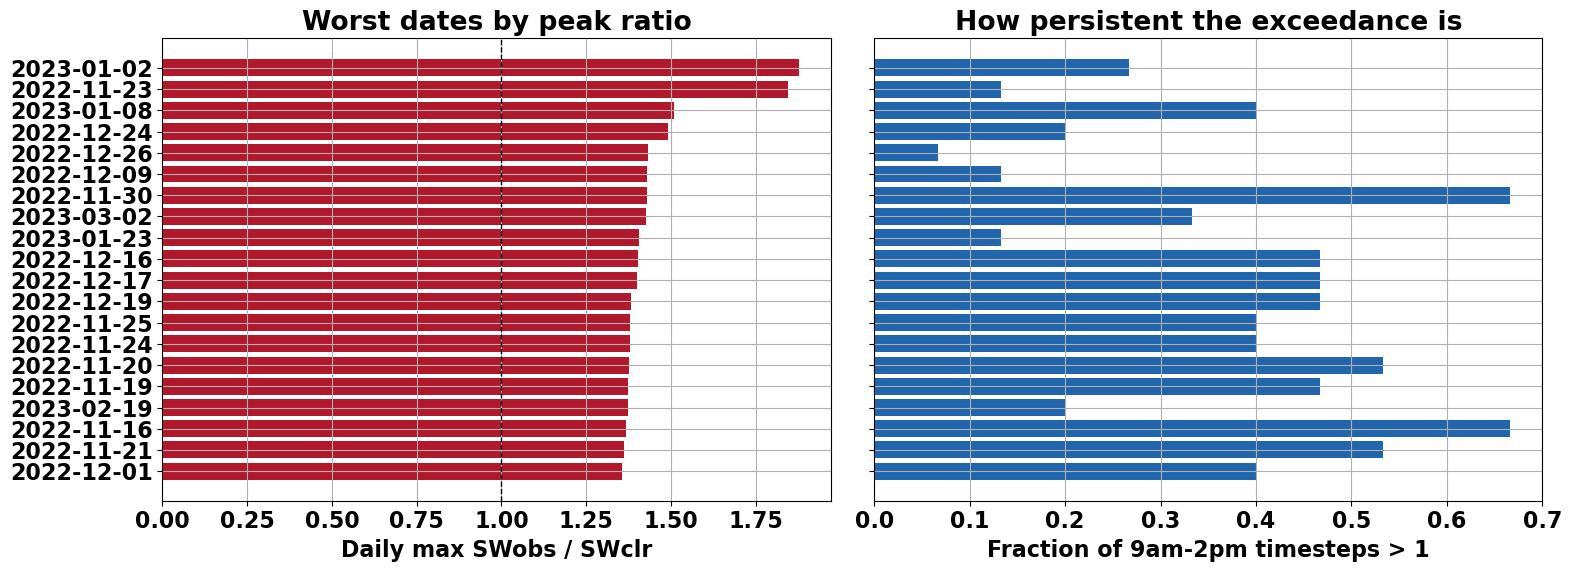

In [12]:
top_n = 20
plot_df = daily_ratio_exceedance.head(top_n).copy()
plot_df["date_label"] = plot_df["date"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

axes[0].barh(plot_df["date_label"], plot_df["max_ratio"], color="#b2182b")
axes[0].axvline(RATIO_EXCEEDANCE_THRESHOLD, color="k", ls="--", lw=1)
axes[0].invert_yaxis()
axes[0].set_xlabel("Daily max SWobs / SWclr")
axes[0].set_title("Worst dates by peak ratio")

axes[1].barh(plot_df["date_label"], plot_df["frac_ratio_gt1"], color="#2166ac")
axes[1].set_xlabel("Fraction of 9am-2pm timesteps > 1")
axes[1].set_title("How persistent the exceedance is")

plt.tight_layout()


In [13]:
# Days where the SW method says cloudy but TSI cloud fraction is low
LOW_TSI_CLOUD_FRACTION_THRESHOLD = 0.20
OUT_SW_CLOUDY_LOW_TSI_DATES = "sw_cloudy_low_tsi_candidate_dates.csv"

sw_cloudy_low_tsi_df = compare_df.loc[
    (compare_df["sw_flag"] == "cloudy")
    & compare_df["tsi_frac"].lt(LOW_TSI_CLOUD_FRACTION_THRESHOLD)
].copy()

daily_sw_cloudy_low_tsi = (
    sw_cloudy_low_tsi_df.groupby("date")
    .agg(
        n_mismatch=("time_local", "size"),
        min_sw_ratio=("sw_ratio", "min"),
        mean_sw_ratio=("sw_ratio", "mean"),
        max_tsi_frac=("tsi_frac", "max"),
        mean_tsi_frac=("tsi_frac", "mean"),
        min_obs_sw=("sw_obs", "min"),
        mean_obs_sw=("sw_obs", "mean"),
        mean_clear_sw=("sw_clear", "mean"),
        first_time=("time_local", "min"),
        last_time=("time_local", "max"),
    )
    .sort_values(["n_mismatch", "min_sw_ratio", "mean_tsi_frac"], ascending=[False, True, True])
    .reset_index()
)
daily_sw_cloudy_low_tsi["date"] = daily_sw_cloudy_low_tsi["date"].dt.date
daily_sw_cloudy_low_tsi.to_csv(OUT_SW_CLOUDY_LOW_TSI_DATES, index=False)

print(
    f"Days with SW cloudy and TSI fraction < {LOW_TSI_CLOUD_FRACTION_THRESHOLD}: "
    f"{len(daily_sw_cloudy_low_tsi)}"
)
print(f"Saved ranked candidate dates to {OUT_SW_CLOUDY_LOW_TSI_DATES}")
display_cols = daily_sw_cloudy_low_tsi.head(25).copy()
numeric_cols = display_cols.select_dtypes(include="number").columns
display_cols[numeric_cols] = display_cols[numeric_cols].round(3)
display_cols


Days with SW cloudy and TSI fraction < 0.2: 22
Saved ranked candidate dates to sw_cloudy_low_tsi_candidate_dates.csv


,date,n_mismatch,min_sw_ratio,mean_sw_ratio,max_tsi_frac,mean_tsi_frac,min_obs_sw,mean_obs_sw,mean_clear_sw,first_time,last_time
0,2022-11-04,3,0.406,0.437,0.132,0.096,130.266,196.212,457.301,2022-11-04 09:30:00,2022-11-04 14:30:00
1,2022-12-12,2,0.307,0.392,0.195,-0.019,26.634,36.424,103.148,2022-12-12 15:30:00,2022-12-12 16:00:00
2,2022-11-10,2,0.315,0.346,0.193,0.191,62.484,85.879,243.960,2022-11-10 15:00:00,2022-11-10 15:30:00
3,2022-12-29,2,0.433,0.447,0.012,0.006,35.742,58.652,129.571,2022-12-29 15:30:00,2022-12-29 16:00:00
4,2022-12-31,1,0.180,0.180,0.039,0.039,14.816,14.816,82.199,2022-12-31 16:00:00,2022-12-31 16:00:00
5,2023-01-01,1,0.224,0.224,0.093,0.093,19.112,19.112,85.284,2023-01-01 16:00:00,2023-01-01 16:00:00
6,2022-12-21,1,0.246,0.246,-0.130,-0.130,15.761,15.761,64.062,2022-12-21 16:00:00,2022-12-21 16:00:00
7,2022-12-28,1,0.247,0.247,0.094,0.094,19.005,19.005,77.042,2022-12-28 16:00:00,2022-12-28 16:00:00
8,2022-11-28,1,0.368,0.368,-0.177,-0.177,21.007,21.007,57.099,2022-11-28 16:00:00,2022-11-28 16:00:00
9,2023-01-17,1,0.373,0.373,0.046,0.046,55.941,55.941,150.023,2023-01-17 16:00:00,2023-01-17 16:00:00


## Direct k_t Ratio vs GOES Cloud Fractions

Compare the continuous shortwave clearness index, `k_t = SWobs / SWclr`, directly against GOES ACM and GOES RGB cloud-mask cloud fractions from the Colorado domain. This uses the same season-specific daylight windows as above: 09:00-14:00 local time for October-February and 08:00-17:00 local time for March-September, with `k_t < 1.05`.


In [14]:
CLOUDY_RATIO = 0.4
CLEAR_RATIO = 0.8

In [15]:
GOES_CLOUD_FRACTION_CSV = Path("/glade/u/home/cdalden/goes_work/analysis/output_08c/colorado_domain_cloud_fraction_14z_00z.csv")
GOES_MATCH_TOLERANCE = pd.Timedelta("3min")
GOES_CLOUD_FRACTION_COLUMNS = {
    "GOES ACM": "acm_cloud_frac",
    "GOES RGB cloud mask": "rgb_cloud_frac",
}

kt_goes_source_df = compare_all_df if "compare_all_df" in globals() else compare_df
kt_goes_sw_df = kt_goes_source_df.dropna(subset=["time_local", "sw_ratio"]).copy()
kt_goes_sw_df = kt_goes_sw_df[np.isfinite(kt_goes_sw_df["sw_ratio"])]

kt_goes_month = kt_goes_sw_df["time_local"].dt.month
kt_goes_hour = kt_goes_sw_df["time_local"].dt.hour + kt_goes_sw_df["time_local"].dt.minute / 60
kt_goes_oct_feb_window = kt_goes_month.isin([10, 11, 12, 1, 2]) & kt_goes_hour.between(9, 14, inclusive="both")
kt_goes_mar_sep_window = kt_goes_month.isin([3, 4, 5, 6, 7, 8, 9]) & kt_goes_hour.between(8, 17, inclusive="both")

kt_goes_sw_df = kt_goes_sw_df.loc[kt_goes_oct_feb_window | kt_goes_mar_sep_window].copy()
kt_goes_sw_df = kt_goes_sw_df.loc[kt_goes_sw_df["sw_ratio"] < 1.05, ["time_local", "sw_ratio"]].copy()
kt_goes_sw_df["time_local"] = _datetime64ns(kt_goes_sw_df["time_local"])
kt_goes_sw_df = kt_goes_sw_df.iloc[np.argsort(kt_goes_sw_df["time_local"].to_numpy(dtype="datetime64[ns]"))].reset_index(drop=True)

goes_cloud_df = pd.read_csv(GOES_CLOUD_FRACTION_CSV, parse_dates=["t"])
goes_cloud_df["time_local"] = (
    goes_cloud_df["t"].dt.tz_localize("UTC").dt.tz_convert(LOCAL_TZ).dt.tz_localize(None)
)
goes_cloud_df["time_local"] = _datetime64ns(goes_cloud_df["time_local"])
goes_cloud_df = goes_cloud_df[["time_local", *GOES_CLOUD_FRACTION_COLUMNS.values()]].copy()
goes_cloud_df = goes_cloud_df.dropna(subset=list(GOES_CLOUD_FRACTION_COLUMNS.values()), how="all")
goes_cloud_df = goes_cloud_df.iloc[np.argsort(goes_cloud_df["time_local"].to_numpy(dtype="datetime64[ns]"))].reset_index(drop=True)

kt_goes_df = pd.merge_asof(
    kt_goes_sw_df,
    goes_cloud_df,
    on="time_local",
    direction="nearest",
    tolerance=GOES_MATCH_TOLERANCE,
).copy()

# Backward-compatible aliases for earlier ACM-only names.
GOES_ACM_CF_CSV = GOES_CLOUD_FRACTION_CSV
kt_acm_sw_df = kt_goes_sw_df
kt_acm_df = kt_goes_df.dropna(subset=["sw_ratio", "acm_cloud_frac"]).copy()
kt_acm_corr = kt_acm_df[["sw_ratio", "acm_cloud_frac"]].corr(method="pearson").iloc[0, 1]
kt_acm_spearman = kt_acm_df[["sw_ratio", "acm_cloud_frac"]].corr(method="spearman").iloc[0, 1]

kt_goes_summary_rows = [
    {
        "dataset": "SW filter",
        "metric": "Valid SW samples after daylight and k_t < 1.05 filters",
        "value": len(kt_goes_sw_df),
    }
]
kt_goes_metrics = {}
for label, column in GOES_CLOUD_FRACTION_COLUMNS.items():
    matched = kt_goes_df.dropna(subset=["sw_ratio", column]).copy()
    pearson = matched[["sw_ratio", column]].corr(method="pearson").iloc[0, 1]
    spearman = matched[["sw_ratio", column]].corr(method="spearman").iloc[0, 1]
    kt_goes_metrics[column] = {
        "label": label,
        "n": len(matched),
        "pearson": pearson,
        "spearman": spearman,
    }
    kt_goes_summary_rows.extend(
        [
            {"dataset": label, "metric": "Samples matched to GOES", "value": len(matched)},
            {"dataset": label, "metric": f"Pearson corr(k_t, {label} cloud fraction)", "value": pearson},
            {"dataset": label, "metric": f"Spearman corr(k_t, {label} cloud fraction)", "value": spearman},
            {"dataset": label, "metric": "Mean k_t", "value": matched["sw_ratio"].mean()},
            {"dataset": label, "metric": "Median k_t", "value": matched["sw_ratio"].median()},
            {"dataset": label, "metric": f"Mean {label} cloud fraction", "value": matched[column].mean()},
            {"dataset": label, "metric": f"Median {label} cloud fraction", "value": matched[column].median()},
        ]
    )

kt_goes_summary = pd.DataFrame(kt_goes_summary_rows)
kt_acm_summary = kt_goes_summary
kt_goes_summary


,dataset,metric,value
0,SW filter,Valid SW samples after daylight and k_t < 1.05...,2800.000000
1,GOES ACM,Samples matched to GOES,2381.000000
2,GOES ACM,"Pearson corr(k_t, GOES ACM cloud fraction)",-0.590858
3,GOES ACM,"Spearman corr(k_t, GOES ACM cloud fraction)",-0.656421
4,GOES ACM,Mean k_t,0.704479
5,GOES ACM,Median k_t,0.772152
6,GOES ACM,Mean GOES ACM cloud fraction,0.666212
7,GOES ACM,Median GOES ACM cloud fraction,0.972222
8,GOES RGB cloud mask,Samples matched to GOES,2427.000000
9,GOES RGB cloud mask,"Pearson corr(k_t, GOES RGB cloud mask cloud fr...",-0.628860


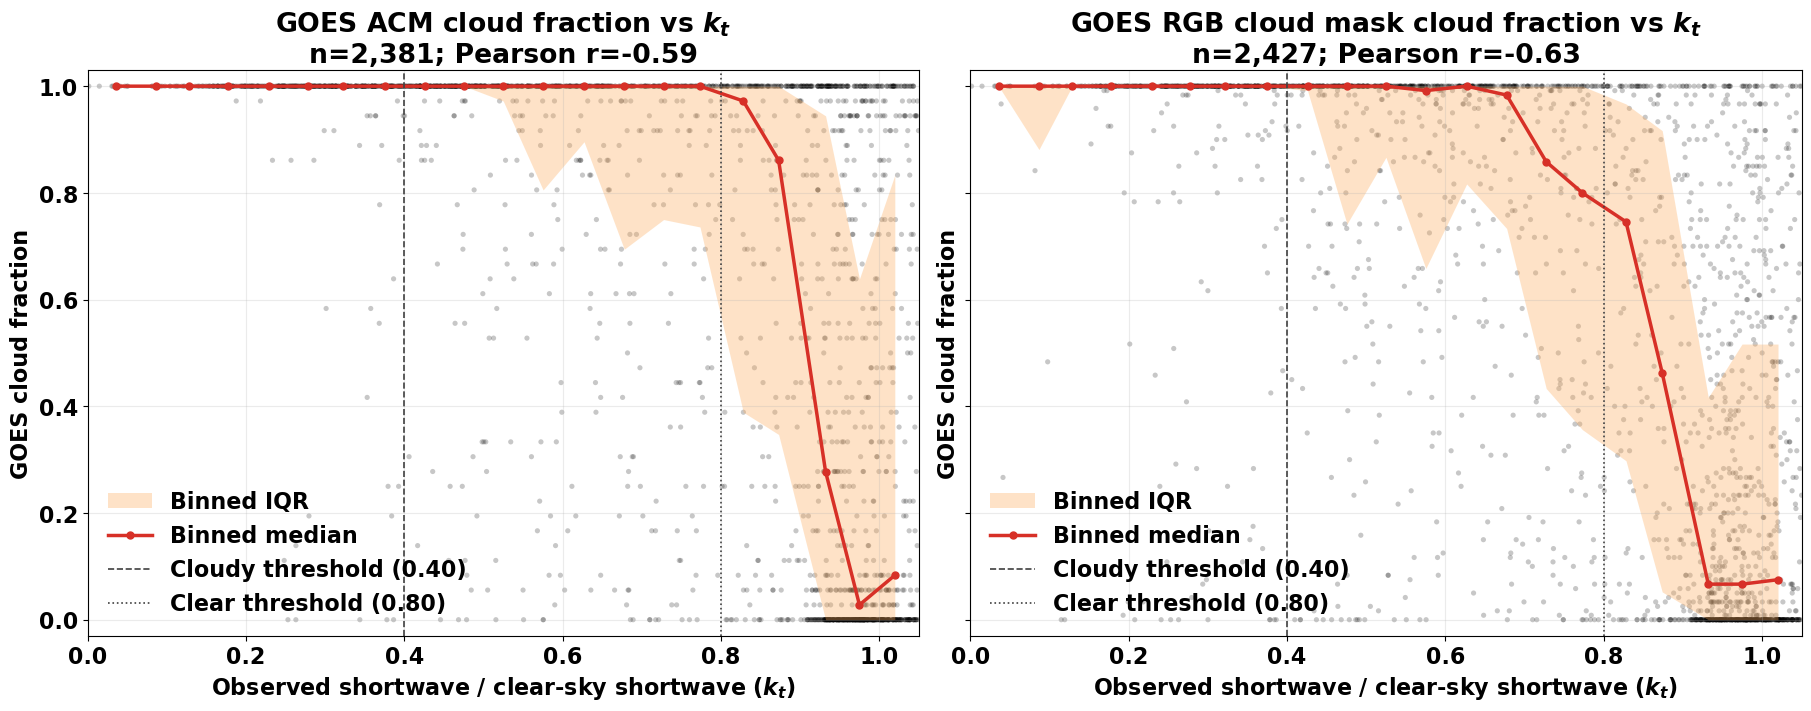

In [16]:
kt_bin_edges = np.arange(0.0, 1.051, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=True, constrained_layout=True)

for ax, (label, column) in zip(axes, GOES_CLOUD_FRACTION_COLUMNS.items()):
    plot_df = kt_goes_df.dropna(subset=["sw_ratio", column]).copy()
    plot_df["kt_bin"] = pd.cut(plot_df["sw_ratio"], kt_bin_edges, include_lowest=True)

    bin_summary = (
        plot_df.groupby("kt_bin", observed=False)
        .agg(
            n=(column, "count"),
            kt_mid=("sw_ratio", "median"),
            cloud_median=(column, "median"),
            cloud_q25=(column, lambda s: s.quantile(0.25)),
            cloud_q75=(column, lambda s: s.quantile(0.75)),
        )
        .dropna(subset=["kt_mid", "cloud_median"])
    )
    bin_summary = bin_summary.loc[bin_summary["n"] >= 5].copy()

    ax.scatter(
        plot_df["sw_ratio"],
        plot_df[column],
        s=14,
        alpha=0.22,
        color="k",
        edgecolors="none",
        rasterized=True,
    )
    ax.fill_between(
        bin_summary["kt_mid"],
        bin_summary["cloud_q25"],
        bin_summary["cloud_q75"],
        color="#fdae61",
        alpha=0.35,
        linewidth=0,
        label="Binned IQR",
    )
    ax.plot(
        bin_summary["kt_mid"],
        bin_summary["cloud_median"],
        color="#d73027",
        marker="o",
        lw=2.5,
        ms=5,
        label="Binned median",
    )

    ax.axvline(CLOUDY_RATIO, color="0.25", ls="--", lw=1.2, label=f"Cloudy threshold ({CLOUDY_RATIO:.2f})")
    ax.axvline(CLEAR_RATIO, color="0.25", ls=":", lw=1.2, label=f"Clear threshold ({CLEAR_RATIO:.2f})")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(-0.03, 1.03)
    ax.set_xlabel("Observed shortwave / clear-sky shortwave ($k_t$)")
    ax.set_title(
        f"{label} cloud fraction vs $k_t$\n"
        f"n={len(plot_df):,}; Pearson r={kt_goes_metrics[column]['pearson']:.2f}"
    )
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("GOES cloud fraction")
axes[0].legend(loc="lower left", frameon=False)

axes[1].set_ylabel("GOES cloud fraction")
axes[1].legend(loc="lower left", frameon=False)

plt.show()


## Direct k_t Ratio vs TSI Cloud Fraction

Compare the continuous shortwave clearness index, `k_t = SWobs / SWclr`, directly against the observed TSI cloud fraction using the same season-specific daylight windows and `k_t < 1.05` filter.


/glade/derecho/scratch/cdalden/tmp/ipykernel_41073/4076537254.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  scatter = axes[0].scatter(


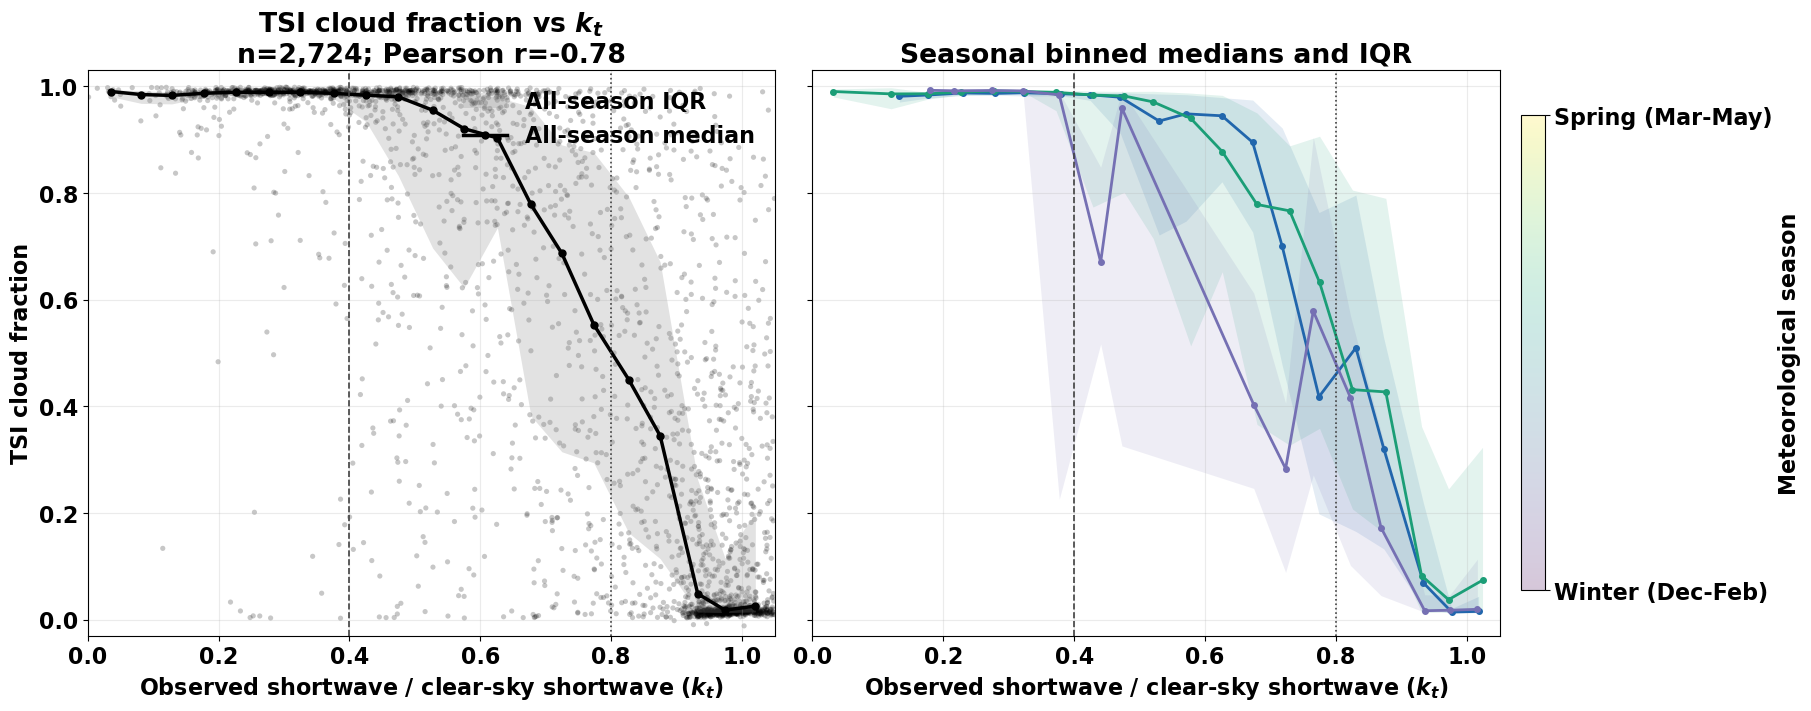

In [17]:
from matplotlib.colors import BoundaryNorm, ListedColormap

kt_tsi_source_df = compare_all_df if "compare_all_df" in globals() else compare_df
kt_tsi_df = kt_tsi_source_df.dropna(subset=["sw_ratio", "tsi_frac"]).copy()
kt_tsi_df = kt_tsi_df[np.isfinite(kt_tsi_df["sw_ratio"]) & np.isfinite(kt_tsi_df["tsi_frac"])]

kt_tsi_month = kt_tsi_df["time_local"].dt.month
kt_tsi_hour = kt_tsi_df["time_local"].dt.hour + kt_tsi_df["time_local"].dt.minute / 60
kt_tsi_oct_feb_window = kt_tsi_month.isin([10, 11, 12, 1, 2]) & kt_tsi_hour.between(9, 14, inclusive="both")
kt_tsi_mar_sep_window = kt_tsi_month.isin([3, 4, 5, 6, 7, 8, 9]) & kt_tsi_hour.between(8, 17, inclusive="both")

kt_tsi_df = kt_tsi_df.loc[kt_tsi_oct_feb_window | kt_tsi_mar_sep_window].copy()
kt_tsi_df = kt_tsi_df.loc[kt_tsi_df["sw_ratio"] < 1.05].copy()

season_by_month = {
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
}
season_order = ["DJF", "MAM", "JJA", "SON"]
season_labels = ["Winter (Dec-Feb)", "Spring (Mar-May)", "Summer (Jun-Aug)", "Fall (Sep-Nov)"]
season_colors = ["#2166ac", "#1b9e77", "#d95f02", "#7570b3"]
kt_tsi_df["met_season"] = kt_tsi_df["time_local"].dt.month.map(season_by_month)
kt_tsi_df["season_code"] = kt_tsi_df["met_season"].map({season: idx for idx, season in enumerate(season_order)})

kt_bin_edges = np.arange(0.0, 1.051, 0.05)
kt_tsi_df["kt_bin"] = pd.cut(kt_tsi_df["sw_ratio"], kt_bin_edges, include_lowest=True)

kt_tsi_bin_summary = (
    kt_tsi_df.groupby("kt_bin", observed=False)
    .agg(
        n=("tsi_frac", "count"),
        kt_mid=("sw_ratio", "median"),
        tsi_median=("tsi_frac", "median"),
        tsi_q25=("tsi_frac", lambda s: s.quantile(0.25)),
        tsi_q75=("tsi_frac", lambda s: s.quantile(0.75)),
    )
    .dropna(subset=["kt_mid", "tsi_median"])
)
kt_tsi_bin_summary = kt_tsi_bin_summary.loc[kt_tsi_bin_summary["n"] >= 5].copy()

season_bin_summary = (
    kt_tsi_df.groupby(["met_season", "kt_bin"], observed=False)
    .agg(
        n=("tsi_frac", "count"),
        kt_mid=("sw_ratio", "median"),
        tsi_median=("tsi_frac", "median"),
        tsi_q25=("tsi_frac", lambda s: s.quantile(0.25)),
        tsi_q75=("tsi_frac", lambda s: s.quantile(0.75)),
    )
    .dropna(subset=["kt_mid", "tsi_median"])
    .reset_index()
)
season_bin_summary = season_bin_summary.loc[season_bin_summary["n"] >= 5].copy()

cmap = ListedColormap(season_colors)
norm = BoundaryNorm(np.arange(-0.5, len(season_order) + 0.5, 1), cmap.N)
kt_tsi_corr = kt_tsi_df[["sw_ratio", "tsi_frac"]].corr(method="pearson").iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=True, constrained_layout=True)

scatter = axes[0].scatter(
    kt_tsi_df["sw_ratio"],
    kt_tsi_df["tsi_frac"],
    c='k',
    norm=norm,
    s=14,
    alpha=0.22,
    edgecolors="none",
    rasterized=True,
)
axes[0].fill_between(
    kt_tsi_bin_summary["kt_mid"],
    kt_tsi_bin_summary["tsi_q25"],
    kt_tsi_bin_summary["tsi_q75"],
    color="0.55",
    alpha=0.25,
    linewidth=0,
    label="All-season IQR",
)
axes[0].plot(
    kt_tsi_bin_summary["kt_mid"],
    kt_tsi_bin_summary["tsi_median"],
    color="k",
    marker="o",
    lw=2.5,
    ms=5,
    label="All-season median",
)
axes[0].legend(loc="upper right", frameon=False)

for season, color in zip(season_order, season_colors):
    season_df = season_bin_summary.loc[season_bin_summary["met_season"] == season]
    if season_df.empty:
        continue
    axes[1].fill_between(
        season_df["kt_mid"],
        season_df["tsi_q25"],
        season_df["tsi_q75"],
        color=color,
        alpha=0.12,
        linewidth=0,
    )
    axes[1].plot(
        season_df["kt_mid"],
        season_df["tsi_median"],
        color=color,
        marker="o",
        lw=2.0,
        ms=4,
    )

for ax in axes:
    ax.axvline(CLOUDY_RATIO, color="0.25", ls="--", lw=1.2)
    ax.axvline(CLEAR_RATIO, color="0.25", ls=":", lw=1.2)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(-0.03, 1.03)
    ax.set_xlabel("Observed shortwave / clear-sky shortwave ($k_t$)")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("TSI cloud fraction")
axes[0].set_title(f"TSI cloud fraction vs $k_t$\nn={len(kt_tsi_df):,}; Pearson r={kt_tsi_corr:.2f}")
axes[1].set_title("Seasonal binned medians and IQR")

cbar = fig.colorbar(scatter, ax=axes, ticks=np.arange(len(season_order)), shrink=0.84, pad=0.015)
cbar.ax.set_yticklabels(season_labels)
cbar.set_label("Meteorological season")

plt.show()
